# Step 54e — Screen `us_overnight_return`

For `FLAGSHIP_6BCEH_SHORT_VWAP_RSI60`. New candidate: S&P 500's most recently
completed session's close-to-close return, correctly aligned to the next India
trading day (`54e_fetch_us_overnight.py`) — genuinely different mechanism from
everything screened so far (global overnight information flow, not another local
magnitude/volatility measure).

Convention: circular-shift only (the correct primary), no iid duplication — this
notebook is not a one-time-exception record like `54c_screen.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.style.use('dark_background')

np.random.seed(42)
N_SHUFFLES = 5000
NEW_FEATURE = 'us_overnight_return'
ALL_CANDIDATES = ['gap_pct', 'nifty_trend_5d', 'nifty_trend_10d', 'realized_vol_nifty_10d',
                   'dist_from_ma50_nifty', 'basket_trend_5d', 'basket_trend_10d', 'dispersion',
                   'breadth', 'realized_vol_basket_10d', 'volume_surge', 'india_vix_level',
                   'us_overnight_return']

trades = pd.read_csv('54c_trade_log_with_features.csv', parse_dates=['signal_dt'])
trades['date'] = trades['signal_dt'].dt.date
print(f'{len(trades):,} trades loaded, {len(ALL_CANDIDATES)} total candidates in the pool')


14,270 trades loaded, 13 total candidates in the pool


## 1. Aggregate to daily level

In [2]:
daily = trades.groupby('date').agg(
    daily_zpnl=('zpnl', 'sum'),
    **{f: (f, 'first') for f in ALL_CANDIDATES}
).reset_index()
daily['profitable_day'] = (daily['daily_zpnl'] > 0).astype(int)

daily_new = daily.dropna(subset=[NEW_FEATURE, 'daily_zpnl']).reset_index(drop=True)
print(f'{len(daily_new):,} trading days retained ({NEW_FEATURE} + target non-null)')
print(f'profitable_day rate: {daily_new.profitable_day.mean():.1%}')
daily_new[[NEW_FEATURE, 'daily_zpnl']].describe()


2,557 trading days retained (us_overnight_return + target non-null)
profitable_day rate: 41.0%


,us_overnight_return,daily_zpnl
count,2557.000000,2557.000000
mean,0.134098,-0.952783
std,0.979780,16.732187
min,-11.984055,-142.276900
25%,-0.291181,-6.513000
50%,0.111362,-1.168800
75%,0.619884,3.703100
max,9.382774,150.460200


## 2. Individual null-calibration (circular-shift)

In [3]:
def individual_null_circular(df, target_col, feature_col):
    y = df[target_col].values.astype(float)
    x = df[feature_col].values
    n = len(y)
    null_r = np.empty(n - 1)
    for shift in range(1, n):
        null_r[shift - 1] = np.corrcoef(x, np.roll(y, shift))[0, 1]
    return null_r

individual_null = {}
for target in ['daily_zpnl', 'profitable_day']:
    individual_null[target] = individual_null_circular(daily_new, target, NEW_FEATURE)

print(f'Individual ceilings, CIRCULAR-SHIFT, {NEW_FEATURE}:')
for target, nulls in individual_null.items():
    c95, c99 = np.percentile(np.abs(nulls), [95, 99])
    real_r = np.corrcoef(daily_new[NEW_FEATURE], daily_new[target])[0, 1]
    print(f'  {target:16s} r={real_r:+.4f}  ceil95={c95:.4f}  ceil99={c99:.4f}')


Individual ceilings, CIRCULAR-SHIFT, us_overnight_return:
  daily_zpnl       r=-0.0267  ceil95=0.0394  ceil99=0.0514
  profitable_day   r=+0.0062  ceil95=0.0384  ceil99=0.0508


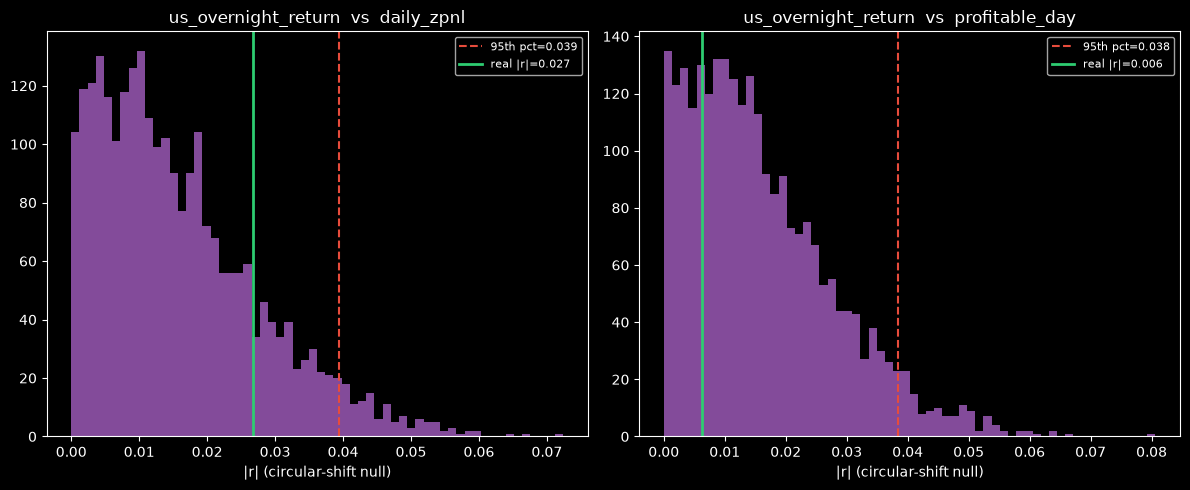

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target in zip(axes, ['daily_zpnl', 'profitable_day']):
    nulls = individual_null[target]
    real_r = np.corrcoef(daily_new[NEW_FEATURE], daily_new[target])[0, 1]
    ceil95 = np.percentile(np.abs(nulls), 95)
    ax.hist(np.abs(nulls), bins=60, color='#9b59b6', alpha=0.85)
    ax.axvline(ceil95, color='#e74c3c', linestyle='--', label=f'95th pct={ceil95:.3f}')
    ax.axvline(abs(real_r), color='#2ecc71', linewidth=2, label=f'real |r|={abs(real_r):.3f}')
    ax.set_title(f'{NEW_FEATURE}  vs  {target}')
    ax.set_xlabel('|r| (circular-shift null)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Combined null-calibration — max-of-13 (all built candidates)

In [5]:
def _pearson_cols(X, y):
    Xc = X - X.mean(axis=0); yc = y - y.mean()
    num = (Xc * yc[:, None]).sum(axis=0)
    den = np.sqrt((Xc**2).sum(axis=0) * (yc**2).sum())
    return num / den

daily_all = daily.dropna(subset=ALL_CANDIDATES + ['daily_zpnl']).reset_index(drop=True)
Xall = daily_all[ALL_CANDIDATES].values
N_CAND = len(ALL_CANDIDATES)
print(f'{len(daily_all):,} days retained (all {N_CAND} candidates + target non-null)')

def combined_null_N_circular(df, X, target_col):
    y = df[target_col].values.astype(float)
    n = len(y)
    max_abs_r = np.empty(n - 1)
    for shift in range(1, n):
        max_abs_r[shift - 1] = np.abs(_pearson_cols(X, np.roll(y, shift))).max()
    return max_abs_r

combined_null_N = {t: combined_null_N_circular(daily_all, Xall, t) for t in ['daily_zpnl', 'profitable_day']}

print('\nReal r, every candidate, sorted by |r| (target=daily_zpnl):')
real_r_zpnl = _pearson_cols(Xall, daily_all['daily_zpnl'].values.astype(float))
for f, r in sorted(zip(ALL_CANDIDATES, real_r_zpnl), key=lambda t: -abs(t[1])):
    marker = '  <-- NEW' if f == NEW_FEATURE else ''
    print(f'  {f:>25}: {r:+.4f}{marker}')

print()
for t, nulls in combined_null_N.items():
    c95, c99 = np.percentile(nulls, [95, 99])
    print(f'  {t:16s} max-of-{N_CAND} ceil95={c95:.4f}  ceil99={c99:.4f}')


2,453 days retained (all 13 candidates + target non-null)



Real r, every candidate, sorted by |r| (target=daily_zpnl):
                    gap_pct: -0.0625
                 dispersion: +0.0575
            india_vix_level: +0.0519
               volume_surge: -0.0506
            nifty_trend_10d: +0.0310
        us_overnight_return: -0.0294  <-- NEW
                    breadth: -0.0212
    realized_vol_basket_10d: +0.0203
     realized_vol_nifty_10d: +0.0193
           basket_trend_10d: +0.0187
            basket_trend_5d: +0.0147
       dist_from_ma50_nifty: +0.0118
             nifty_trend_5d: +0.0107

  daily_zpnl       max-of-13 ceil95=0.0637  ceil99=0.0812
  profitable_day   max-of-13 ceil95=0.0617  ceil99=0.0712


## 4. The real screen — actual r, both ceiling scopes shown

In [6]:
results = []
for target_col in ['daily_zpnl', 'profitable_day']:
    r_real = np.corrcoef(daily_new[NEW_FEATURE].values, daily_new[target_col].values)[0, 1]

    ind_nulls = individual_null[target_col]
    ind_ceil95, ind_ceil99 = np.percentile(np.abs(ind_nulls), [95, 99])
    emp_p_ind = (np.abs(ind_nulls) >= abs(r_real)).mean()

    r_wide = np.corrcoef(daily_all[NEW_FEATURE].values, daily_all[target_col].values)[0, 1]
    combN_nulls = combined_null_N[target_col]
    combN_ceil95, combN_ceil99 = np.percentile(combN_nulls, [95, 99])

    n = len(daily_new)
    t_stat = r_real * np.sqrt((n - 2) / (1 - r_real**2))
    textbook_p = 2 * stats.t.sf(abs(t_stat), n - 2)

    results.append(dict(
        target=target_col, feature=NEW_FEATURE, r=round(r_real, 4),
        clears_individual_95=abs(r_real) > ind_ceil95,
        clears_individual_99=abs(r_real) > ind_ceil99,
        emp_p_individual=round(emp_p_ind, 4),
        r_wide_sample=round(r_wide, 4),
        clears_maxN_95=abs(r_wide) > combN_ceil95,
        clears_maxN_99=abs(r_wide) > combN_ceil99,
        textbook_p=round(textbook_p, 6),
    ))

results_df = pd.DataFrame(results)
results_df


,target,feature,r,clears_individual_95,clears_individual_99,emp_p_individual,r_wide_sample,clears_maxN_95,clears_maxN_99,textbook_p
0,daily_zpnl,us_overnight_return,-0.0267,False,False,0.1749,-0.0294,False,False,0.176742
1,profitable_day,us_overnight_return,0.0062,False,False,0.7719,0.0053,False,False,0.753197


## 5. Visual sanity check — scatter + quartile-bucket comparison

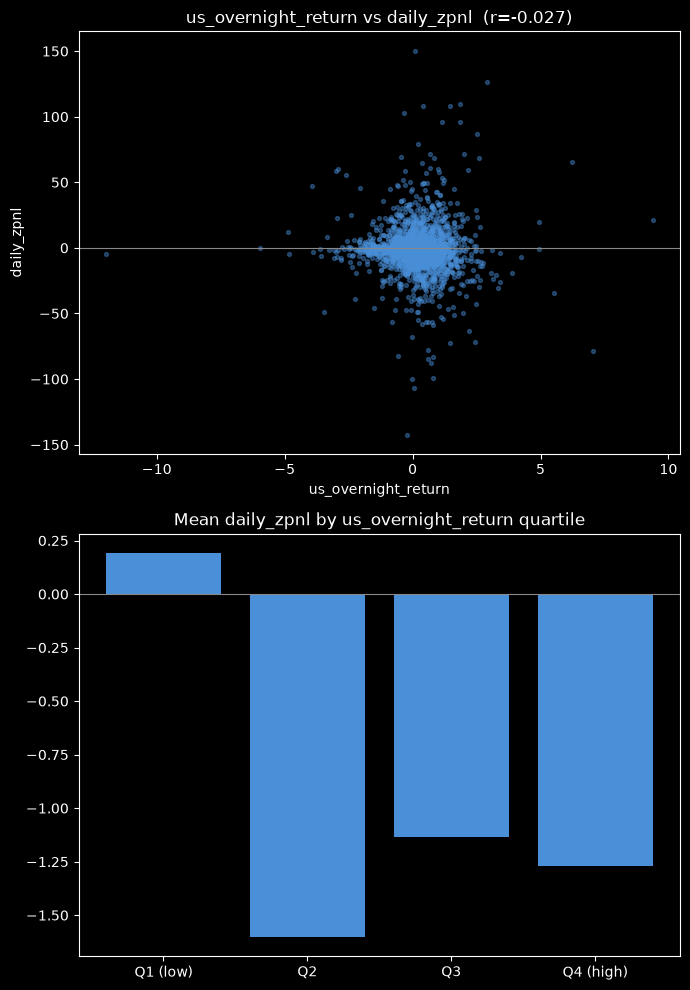

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(7, 10))
axes[0].scatter(daily_new[NEW_FEATURE], daily_new['daily_zpnl'], s=8, alpha=0.4, color='#4a90d9')
axes[0].axhline(0, color='#888', linewidth=0.8)
axes[0].set_xlabel(NEW_FEATURE); axes[0].set_ylabel('daily_zpnl')
r_val = results_df[results_df.target == 'daily_zpnl']['r'].iloc[0]
axes[0].set_title(f'{NEW_FEATURE} vs daily_zpnl  (r={r_val:.3f})')

daily_new[f'{NEW_FEATURE}_q'] = pd.qcut(daily_new[NEW_FEATURE], 4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
bucket_means = daily_new.groupby(f'{NEW_FEATURE}_q', observed=True)['daily_zpnl'].mean()
axes[1].bar(bucket_means.index.astype(str), bucket_means.values, color='#4a90d9')
axes[1].axhline(0, color='#888', linewidth=0.8)
axes[1].set_title(f'Mean daily_zpnl by {NEW_FEATURE} quartile')
plt.tight_layout()
plt.show()


## 6. Theory check

`us_overnight_return` tests a genuinely distinct, well-documented market-microstructure
mechanism: overnight information flow from US markets (the world's largest, most liquid
equity market, trading while India is closed) into India's next-day open. This is
different in kind from everything else screened:
- Not a magnitude/volatility feature (dispersion, volume_surge, india_vix_level) —
  it's directional, like `nifty_trend_10d`/`gap_pct`.
- But unlike `nifty_trend_10d` (dead on weak-form efficiency -- purely a function of
  INDIA's own past prices, which the theory says carries no information), this
  feature's information originates from a DIFFERENT market entirely. Weak-form
  efficiency is a claim about a market's own price history predicting its own future
  returns -- it says nothing about whether one market's fresh, only-just-priced-in
  information transmits to another market that was closed while it happened. Global
  cross-market spillover (US closing moves affecting next-day Asian/Indian opens) is
  a distinct, separately studied phenomenon in the literature, not ruled out by the
  same argument that killed `nifty_trend_10d`.
- Closer in spirit to `gap_pct` (which was flagged as the "mixed case, needs care" --
  directional but with a plausible information-flow story) -- this feature is
  arguably a *cleaner* version of that same idea, since it isolates a specific,
  identifiable causal channel (US overnight moves) rather than gap_pct's more
  general "something happened overnight" measure (gap_pct can't distinguish a
  US-driven gap from a domestic-news-driven gap).

## 7. Verdict

In [8]:
print(results_df.to_string(index=False))
print()
passed = results_df[results_df.clears_individual_95]
print(f'Clears individual circular-shift 95th: {len(passed)} of {len(results_df)} pairs')
print()
passed_both = results_df[results_df.clears_individual_95 & results_df.clears_maxN_95]
print(f'Clears BOTH individual AND max-of-{len(ALL_CANDIDATES)} 95th: {len(passed_both)} of {len(results_df)} pairs')
print()
if len(passed_both) == 0:
    print(f'{NEW_FEATURE} does not survive the full screen -- same fate as every other')
    print('candidate tested this session, despite the genuinely distinct theoretical mechanism.')
    print('No OOS gate test warranted.')
else:
    print(f'{NEW_FEATURE} survives the full statistical screen -- next step is an OOS gate')
    print('test (chronological 70/30 split, cutoff from TRAIN only) before any enthusiasm,')
    print('same discipline every prior candidate went through.')


        target             feature       r  clears_individual_95  clears_individual_99  emp_p_individual  r_wide_sample  clears_maxN_95  clears_maxN_99  textbook_p
    daily_zpnl us_overnight_return -0.0267                 False                 False            0.1749        -0.0294           False           False    0.176742
profitable_day us_overnight_return  0.0062                 False                 False            0.7719         0.0053           False           False    0.753197

Clears individual circular-shift 95th: 0 of 2 pairs

Clears BOTH individual AND max-of-13 95th: 0 of 2 pairs

us_overnight_return does not survive the full screen -- same fate as every other
candidate tested this session, despite the genuinely distinct theoretical mechanism.
No OOS gate test warranted.
